# D — Planetary Growth Evolution: Accretion Timescales and Composition Tracing

This notebook reconstructs the **temporal evolution of planetary accretion** 
by tracing collision/merger histories and tracking composition changes in real time:

**Key steps:**
1. Load N-body simulation snapshots and classify initial planetesimals by orbital zone (EF/EC/OC/CI)
2. Build initial composition dictionary mapping particle ID → chondrite fractions
3. Identify final planetary bodies (Earth-like: 0.7-1.3 M⊕, Mars-like: 0.05-0.3 M⊕)
4. Load collision records and filter gas disk vs. post-gas disk phases
5. Trace full collision histories with **real-time composition tracking**
   - For each merger: combine parent compositions (mass-weighted)
   - Update product particle with accumulated composition
6. Extract individual planet histories filtered by final particle ID
7. Fit growth models to mass evolution curves (exponential + sigmoidal models)
8. Compute key timescales: when planets reached 40%, 60%, 80% of final mass
9. Visualize temporal composition evolution as stacked area plots
10. Export growth timescale statistics to CSV

**Output:** `./Tables/{Model}_evolution_timescales.csv`

> **Prerequisites:**
> - N-body dataset available at `./N_body_dataset/{model}/` with `aei*.txt` and `Collision*.txt` files
> - `accrediff` module with `CollisionTracer`, `GrowthFitter`, `GrowthModel` classes
>
> **Input:** N-body aei snapshots + Collision file  
> **Output:** Planet growth timescales + composition evolution tracks

**Physical Model:**

The accretion process involves sequential mergers:
$$\text{Particle } i + \text{Particle } j \xrightarrow{\text{collision at } t} \text{Product (ID)} \xrightarrow{\text{inherits}} (X_{\text{EF}}, X_{\text{EC}}, X_{\text{OC}}, X_{\text{CI}})$$

**Key assumption:** Compositions mix conservatively (mass-weighted sum)
$$X_{\text{comp,product}} = \frac{m_i \cdot X_{\text{comp},i} + m_j \cdot X_{\text{comp},j}}{m_i + m_j}$$

This allows us to track how planetary compositions evolve from **homogeneous planetesimals** 
to **heterogeneous planets** during the assembly process.

In [1]:
# ============================================================================
# SETUP & CONFIGURATION
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys
import pathlib
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

sys.path.append('../../src')
import accrediff as ad

# ── Plot style (Nature-style) ────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "figure.dpi": 150,
    "xtick.major.size": 8,
    "xtick.minor.size": 5,
    "xtick.major.width": 1.3,
    "xtick.minor.width": 1.0,
})

# ── Color palette ────────────────────────────────────────────────
Colors = {
    'Earth': "#1f77b4",
    'Mars': "#d62728",
    'EF': "#8c564b",
    'EC': "#ff7f0e",
    'OC': "#2ca02c",
    'CI': "#9467bd",
    'UPB_Fe': "#e377c2",
    'UPB_Mg': "#7f7f7f",
}

# ── Model configuration ──────────────────────────────────────────
model_list = ['note_02', 'demo_32', 'demo_33', 'demo_39', 'demo_48', 'demo_53']
Model = model_list[0]  # Select model
base_path = '../dataset/N_body_dataset/'
model_path = os.path.join(base_path, Model)

# ── Chondrite types ─────────────────────────────────────────────
composition_types = ['EF', 'EC', 'OC', 'CI']

print("✅ Setup complete.")
print(f"Model              : {Model}")
print(f"Chondrite types    : {composition_types}")
print(f"Colors configured  : {len(Colors)} entries")

✅ Setup complete.
Model              : note_02
Chondrite types    : ['EF', 'EC', 'OC', 'CI']
Colors configured  : 8 entries


---
## 1. Load N-body Simulation Data

Load all orbital element snapshots from the N-body simulation.
Each snapshot contains orbital parameters at a specific time point.

**Key columns:**
- `t` — simulation time (years)
- `i` — particle index (0=Jupiter, 1=Saturn, 2+=bodies)
- `a`, `e` — orbital elements
- `m` — mass in solar units → convert to Earth masses

In [2]:
# ============================================================================
# SECTION 1: LOAD N-BODY SNAPSHOTS
# ============================================================================

# ── Locate and load all aei files ────────────────────────────────
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model path {model_path} not found")

file_paths = sorted([
    os.path.join(model_path, f) for f in os.listdir(model_path) 
    if f.startswith('aei')
])

if not file_paths:
    raise FileNotFoundError(f"No aei files found in {model_path}")

# ── Create time keys based on actual file count ──────────────────
keys = [f'{i/10:.1f} Myr' for i in range(len(file_paths))]
time_end = keys[-1]

# ── Load all snapshots ───────────────────────────────────────────
col_names = ['t', 'i', 'a', 'e', 'inc', 'Omega', 'w', 'T', 'E', 'M', 'm', 'r']
A_dict = {}

for path, key in zip(file_paths, keys):
    A_dict[key] = pd.read_csv(
        path, sep=' ', header=None, names=col_names, index_col='i'
    )
    # Convert mass to Earth units
    A_dict[key]['m_e'] = A_dict[key]['m'] / ad.constants.ME

print(f"✓ Loaded {len(A_dict)} snapshots")
print(f"  Time range    : {keys[0]:>6s} → {time_end:>6s}")
print(f"  Time interval : {(float(keys[1].split()[0]) - float(keys[0].split()[0])):.1f} Myr")
print()

✓ Loaded 1001 snapshots
  Time range    : 0.0 Myr → 100.0 Myr
  Time interval : 0.1 Myr



---
## 2. Initial Composition Classification (t = 0 Myr)

At t=0, assign each planetesimal a chondrite type based on its semi-major axis:

$$\begin{cases}
\text{EF} & a \leq 1.0 \text{ AU} \\
\text{EC} & 1.0 < a \leq 1.3 \text{ AU} \\
\text{OC} & 1.3 < a \leq 3.0 \text{ AU} \\
\text{CI} & a > 3.0 \text{ AU}
\end{cases}$$

Build a **composition dictionary** mapping each particle ID to its initial fractions:
$$\text{comp}[\text{pid}] = \{X_{\text{EF}}, X_{\text{EC}}, X_{\text{OC}}, X_{\text{CI}}\}$$

This will be **updated dynamically** as particles merge.

In [3]:
# ============================================================================
# SECTION 2: INITIAL COMPOSITION CLASSIFICATION
# ============================================================================

# ── Get initial planetesimal distribution ────────────────────────
time_zero = keys[0]  # First snapshot
df_initial = A_dict[time_zero][['a', 'e', 'inc', 'm_e']].iloc[2:].copy()

# ── Classify by semi-major axis ──────────────────────────────────
conditions = [
    (df_initial['a'] <= 1.0),
    (df_initial['a'] > 1.0) & (df_initial['a'] <= 1.3),
    (df_initial['a'] > 1.3) & (df_initial['a'] <= 3.0),
    (df_initial['a'] > 3.0)
]

df_initial['com'] = np.select(conditions, composition_types, default=None)

# ── Build composition dictionary ─────────────────────────────────
# ✅ Initialize: each particle gets its assigned composition type
for col in composition_types:
    df_initial[col] = 0.0

# Assign mass to corresponding composition column
for idx in df_initial.index:
    com_type = df_initial.loc[idx, 'com']
    if com_type in composition_types:
        df_initial.at[idx, com_type] = df_initial.loc[idx, 'm_e']

# Extract composition as nested dictionary
# composition_dict[pid] = {'EF': x, 'EC': 0, 'OC': 0, 'CI': 0}
initial_composition = df_initial[composition_types].to_dict('index')

# ── Create reverse mapping (particle ID → composition type) ──────
i_com_mapping = dict(zip(df_initial.index, df_initial['com']))

print(f"✓ Initial planetesimal composition classified at t = {time_zero}:")
print(f"  EF particles : {(df_initial['com'] == 'EF').sum():3d} → {(df_initial['EF'] > 0).sum():3d} with mass")
print(f"  EC particles : {(df_initial['com'] == 'EC').sum():3d} → {(df_initial['EC'] > 0).sum():3d} with mass")
print(f"  OC particles : {(df_initial['com'] == 'OC').sum():3d} → {(df_initial['OC'] > 0).sum():3d} with mass")
print(f"  CI particles : {(df_initial['com'] == 'CI').sum():3d} → {(df_initial['CI'] > 0).sum():3d} with mass")
print()
print(f"✓ Composition dictionary initialized: {len(initial_composition)} entries")
print(f"  Example (PID={list(initial_composition.keys())[0]}): {list(initial_composition.values())[0]}")
print()

✓ Initial planetesimal composition classified at t = 0.0 Myr:
  EF particles : 2511 → 2511 with mass
  EC particles : 2493 → 2493 with mass
  OC particles : 1506 → 1506 with mass
  CI particles : 490 → 490 with mass

✓ Composition dictionary initialized: 7000 entries
  Example (PID=2): {'EF': 0.0009442291042291043, 'EC': 0.0, 'OC': 0.0, 'CI': 0.0}



---
## 3. Identify Target Planets at Simulation End

Select planets matching our classification criteria:
- **Earth-like:** $0.7 M_\oplus \leq m < 1.3 M_\oplus$
- **Mars-like:** $0.05 M_\oplus \leq m < 0.3 M_\oplus$

In [4]:
# ============================================================================
# SECTION 3: IDENTIFY TARGET PLANETS
# ============================================================================

# ── Get final snapshot and classify bodies ───────────────────────
df_end = A_dict[time_end][['a', 'e', 'inc', 'm_e']].iloc[2:].copy()

# ── Vectorized classification ────────────────────────────────────
class_conditions = [
    df_end['m_e'].between(0.7, 1.3, inclusive='both'),   # Earth-like
    df_end['m_e'].between(0.05, 0.3, inclusive='both'),  # Mars-like
]
choices = ['Earth_like', 'Mars_like']
df_end['Class'] = np.select(class_conditions, choices, default='others')

# ── Filter and sort by mass ──────────────────────────────────────
df_planets = (
    df_end[df_end['Class'].isin(['Earth_like', 'Mars_like'])]
    .sort_values(by='m_e', ascending=False)
)
planets_index = df_planets.index.tolist()

# ── Generate unique keys ─────────────────────────────────────────
class_counter = {}
keys_planets = []
for cls in df_planets['Class']:
    class_counter[cls] = class_counter.get(cls, 0) + 1
    keys_planets.append(f"{cls}_{class_counter[cls]}")

# ── Extract indices by class ─────────────────────────────────────
Earth_like_index = df_planets[df_planets['Class'] == 'Earth_like'].index.tolist()
Mars_like_index = df_planets[df_planets['Class'] == 'Mars_like'].index.tolist()

print(f"✓ Target planets identified at t = {time_end}:")
print(f"  Earth-like (m ∈ [0.7, 1.3] M⊕) : {len(Earth_like_index)} → {Earth_like_index}")
print(f"  Mars-like (m ∈ [0.05, 0.3] M⊕)  : {len(Mars_like_index)} → {Mars_like_index}")
print()
print(f"✓ Planet registry:")
for i, (key, idx) in enumerate(zip(keys_planets, planets_index)):
    mass = df_planets.loc[idx, 'm_e']
    print(f"  {i+1}. {key:15s} → Particle ID {idx:3d}, Final mass {mass:.3f} M⊕")
print()

✓ Target planets identified at t = 100.0 Myr:
  Earth-like (m ∈ [0.7, 1.3] M⊕) : 1 → [4189]
  Mars-like (m ∈ [0.05, 0.3] M⊕)  : 1 → [4755]

✓ Planet registry:
  1. Earth_like_1    → Particle ID 4189, Final mass 0.842 M⊕
  2. Mars_like_1     → Particle ID 4755, Final mass 0.082 M⊕



---
## 4. Load and Filter Collision Records

Collision records track all merger events. We filter by:
- **Gas disk phase:** t ≤ $t_{\text{gas}}$ (initial 0-5 Myr, defined by simulation)
- **Post-gas disk phase:** t > $t_{\text{gas}}$ (late-stage planetary assembly)

We analyze **post-gas disk collisions** where planets form.

In [5]:
# ============================================================================
# SECTION 4: LOAD COLLISION RECORDS
# ============================================================================

# ── Locate collision file ────────────────────────────────────────
collision_files = [
    os.path.join(model_path, f) for f in os.listdir(model_path) 
    if f.startswith('Collision')
]

if not collision_files:
    raise FileNotFoundError(f"No Collision file found in {model_path}")

# ── Load collision data ──────────────────────────────────────────
col_names_c = [
    'time',
    'indexi', 'mi', 'ri', 'xi', 'yi', 'zi', 'vxi', 'vyi', 'vzi', 'Sxi', 'Syi', 'Szi',
    'indexj', 'mj', 'rj', 'xj', 'yj', 'zj', 'vxj', 'vyj', 'vzj', 'Sxj', 'Syj', 'Szj',
]

try:
    C_data = pd.read_csv(collision_files[0], sep=r'\s+', header=None, names=col_names_c)
    C_data['m_ei'] = C_data['mi'] / ad.constants.ME
    C_data['m_ej'] = C_data['mj'] / ad.constants.ME
except Exception as e:
    raise ValueError(f"Failed to read collision file: {e}")

# ── Filter: post-gas disk phase (t > t_gas) ─────────────────────
# ✅ Extract gas disk end time from first snapshot
gas_time_yr = A_dict[keys[0]]['t'].iloc[0]
C_nogas = C_data[C_data['time'] > gas_time_yr].copy()

# ── Resolve product IDs and sort ─────────────────────────────────
C_nogas.loc[:, 'product_id'] = C_nogas.apply(ad.resolve_product_id, axis=1)
collision_df = C_nogas[['time', 'indexi', 'm_ei', 'indexj', 'm_ej', 'product_id']].sort_values(
    by='time', ascending=True
)

print(f"✓ Collision records loaded and filtered:")
print(f"  Gas disk end time     : {gas_time_yr/1e6:.2f} Myr")
print(f"  Total collisions      : {len(C_data)}")
print(f"  Post-gas disk events  : {len(collision_df)}")
print(f"  Time range            : {collision_df['time'].min()/1e6:.2f} - {collision_df['time'].max()/1e6:.2f} Myr")
print()

✓ Collision records loaded and filtered:
  Gas disk end time     : 0.00 Myr
  Total collisions      : 5790
  Post-gas disk events  : 5790
  Time range            : 0.00 - 96.53 Myr



---
## 5. Define Composition Tracing Function

The core algorithm: for each collision, **combine parent compositions** and 
assign to the product particle.

**Algorithm:**
1. Start with initial composition dictionary
2. For each collision event (i, j) → product:
   - Retrieve parent compositions: $X_i$, $X_j$
   - Mass-weighted sum: $X_{\text{product}} = \frac{m_i X_i + m_j X_j}{m_i + m_j}$
   - Update dictionary: $X[\text{product}] \leftarrow X_{\text{product}}$
3. Record composition at each event → build evolution history

In [6]:
# ============================================================================
# SECTION 5: COMPOSITION TRACING FUNCTION
# ============================================================================

def trace_history_with_composition(tracer, target_id, initial_composition, composition_cols):
    """
    Trace collision history and track composition evolution in real-time.
    
    **Algorithm:**
    1. Trace full merger history backward from target_id
    2. For each collision event, combine parent compositions
    3. Update product particle with new composition
    4. Return enriched history with composition columns
    
    Parameters:
        tracer (CollisionTracer): Initialized tracer object
        target_id (int): Final particle ID to trace
        initial_composition (dict): composition[pid] = {comp_type: mass}
        composition_cols (list): ['EF', 'EC', 'OC', 'CI']
    
    Returns:
        pd.DataFrame: History with columns [time, indexi, indexj, ..., EF, EC, OC, CI, EF_frac, ...]
    """
    
    # ── Trace collision history ──────────────────────────────────
    history_df = tracer.trace_full_history(target_id).copy()
    
    if history_df.empty:
        print(f"⚠ Warning: No collision history for particle {target_id}")
        for col in composition_cols:
            history_df[col] = []
        return history_df
    
    # ── Initialize dynamic composition tracker ────────────────────
    # Deep copy to avoid modifying original dictionary
    current_composition = {pid: comp.copy() for pid, comp in initial_composition.items()}
    
    # ── Process each collision event ─────────────────────────────
    composition_records = []
    
    for _, row in history_df.iterrows():
        i_id = int(row['indexi'])
        j_id = int(row['indexj'])
        product_id = int(row['product_id'])
        m_i = float(row['m_ei'])
        m_j = float(row['m_ej'])
        
        # Get parent compositions (or zeros if not in dict)
        comp_i = current_composition.get(i_id, {c: 0.0 for c in composition_cols})
        comp_j = current_composition.get(j_id, {c: 0.0 for c in composition_cols})
        
        # ✅ Mass-weighted composition averaging
        total_mass = m_i + m_j
        if total_mass > 0:
            new_comp = {
                col: (m_i * comp_i.get(col, 0) + m_j * comp_j.get(col, 0)) / total_mass 
                for col in composition_cols
            }
        else:
            new_comp = {col: 0.0 for col in composition_cols}
        
        # Update product particle composition
        current_composition[product_id] = new_comp
        composition_records.append(new_comp)
    
    # ── Add composition columns to history ────────────────────────
    comp_df = pd.DataFrame(composition_records)
    for col in composition_cols:
        history_df[col] = comp_df[col].values
    
    # ── Compute fractional compositions ──────────────────────────
    total_comp_mass = history_df[composition_cols].sum(axis=1)
    total_comp_mass = total_comp_mass.replace(0, np.nan)  # Avoid division by zero
    
    for col in composition_cols:
        history_df[f'{col}_frac'] = history_df[col] / total_comp_mass
    
    return history_df


# ── Initialize tracer and trace all planets ──────────────────────
tracer = ad.CollisionTracer(collision_df)
pl_history_dict = {}

print(f"✓ Tracing collision histories with composition tracking:")

for key, planet_idx in zip(keys_planets, planets_index):
    history = trace_history_with_composition(
        tracer, 
        planet_idx, 
        initial_composition,
        composition_types
    )
    
    # ── Add derived columns ──────────────────────────────────────
    history['Time'] = history['time'] / 1e6  # Convert to Myr
    history['Mass'] = history['m_ei'] + history['m_ej']  # Collision mass
    
    # Cumulative mass: sum of all merged masses
    history['Mass_cum'] = history['Mass'].cumsum()
    
    # Normalized mass ratio (0 to 1)
    final_mass = history['Mass_cum'].iloc[-1]
    if final_mass > 0:
        history['M_ratio'] = history['Mass_cum'] / final_mass
    else:
        history['M_ratio'] = np.nan
    
    pl_history_dict[key] = history
    
    print(f"  {key:15s}: {len(history):3d} events, mass range [{history['Mass'].min():.4f}, {history['Mass'].max():.4f}] M⊕")

print()

✓ Tracing collision histories with composition tracking:
  Earth_like_1   : 1051 events, mass range [0.0010, 0.8416] M⊕
  Mars_like_1    : 100 events, mass range [0.0011, 0.0819] M⊕



---
## 6. Extract and Filter Individual Planet Histories

From the full merger tree, extract rows where the collision **product** is the final planet ID.
This gives the direct accretion history of that specific planet.

In [7]:
# ============================================================================
# SECTION 6: EXTRACT INDIVIDUAL PLANET HISTORIES
# ============================================================================

print(f"✓ Extracting individual planet accretion histories:")
print()

# ── Extract Earth-like planet history ────────────────────────────
if len(Earth_like_index) > 0:
    earth_planet_key = keys_planets[0]  # First Earth-like planet
    earth_planet_id = planets_index[0]
    
    Earth_like = pl_history_dict[earth_planet_key][
        pl_history_dict[earth_planet_key]['product_id'] == earth_planet_id
    ].copy()
    
    if Earth_like.empty:
        # If no direct matches, use full history (particle may be primary accretor)
        Earth_like = pl_history_dict[earth_planet_key].copy()
    
    Earth_like = Earth_like.sort_values('Time').reset_index(drop=True)
    
    print(f"  Earth_like planet (ID {earth_planet_id}):")
    print(f"    Accretion events : {len(Earth_like)}")
    print(f"    Time range       : {Earth_like['Time'].min():.2f} - {Earth_like['Time'].max():.2f} Myr")
    print(f"    Final mass       : {Earth_like['Mass'].iloc[-1]:.3f} M⊕")
    print(f"    Composition      : EF={Earth_like['EF_frac'].iloc[-1]:.3f}, " +
          f"EC={Earth_like['EC_frac'].iloc[-1]:.3f}, " +
          f"OC={Earth_like['OC_frac'].iloc[-1]:.3f}, " +
          f"CI={Earth_like['CI_frac'].iloc[-1]:.3f}")
    print()
else:
    Earth_like = pd.DataFrame()
    print("  ⚠ No Earth-like planet found")
    print()

# ── Extract Mars-like planet history ─────────────────────────────
if len(Mars_like_index) > 0:
    mars_planet_key = keys_planets[1] if len(keys_planets) > 1 else None
    mars_planet_id = planets_index[1] if len(planets_index) > 1 else None
    
    if mars_planet_key and mars_planet_id:
        Mars_like = pl_history_dict[mars_planet_key][
            pl_history_dict[mars_planet_key]['product_id'] == mars_planet_id
        ].copy()
        
        if Mars_like.empty:
            Mars_like = pl_history_dict[mars_planet_key].copy()
        
        Mars_like = Mars_like.sort_values('Time').reset_index(drop=True)
        
        print(f"  Mars_like planet (ID {mars_planet_id}):")
        print(f"    Accretion events : {len(Mars_like)}")
        print(f"    Time range       : {Mars_like['Time'].min():.2f} - {Mars_like['Time'].max():.2f} Myr")
        print(f"    Final mass       : {Mars_like['Mass'].iloc[-1]:.3f} M⊕")
        print(f"    Composition      : EF={Mars_like['EF_frac'].iloc[-1]:.3f}, " +
              f"EC={Mars_like['EC_frac'].iloc[-1]:.3f}, " +
              f"OC={Mars_like['OC_frac'].iloc[-1]:.3f}, " +
              f"CI={Mars_like['CI_frac'].iloc[-1]:.3f}")
        print()
    else:
        Mars_like = pd.DataFrame()
        print("  ⚠ No Mars-like planet found")
        print()
else:
    Mars_like = pd.DataFrame()
    print("  ⚠ No Mars-like planet found")
    print()

✓ Extracting individual planet accretion histories:

  Earth_like planet (ID 4189):
    Accretion events : 158
    Time range       : 0.01 - 96.53 Myr
    Final mass       : 0.842 M⊕
    Composition      : EF=0.309, EC=0.403, OC=0.277, CI=0.011

  Mars_like planet (ID 4755):
    Accretion events : 31
    Time range       : 0.01 - 53.39 Myr
    Final mass       : 0.082 M⊕
    Composition      : EF=0.180, EC=0.264, OC=0.532, CI=0.024



---
## 7. Fit Growth Models to Mass Evolution

Fit exponential and sigmoidal growth models to the observed mass evolution curves.

**Growth models:**
- **Exponential:** $M(t) = M_f (1 - e^{-t/\tau})$ (runaway accretion)
- **Sigmoidal:** $M(t) = M_f / (1 + e^{-(t-t_0)/\sigma})$ (oligarchic accretion)

where $\tau$ is the growth timescale (smaller = faster accretion)

In [8]:
# ============================================================================
# SECTION 7: FIT GROWTH MODELS (完整修正版)
# ============================================================================

print(f"✓ Fitting growth models to mass evolution curves:")
print()

# ── Fit models if planet data available ──────────────────────────
if not Earth_like.empty:
    try:
        fitter = ad.GrowthFitter()
        
        Ea_t_val = Earth_like['Time'].values
        Ea_tau_raw = fitter.fit_earth_growth_tau(Earth_like, ['Mass_cum'])
        
        # ✅ 处理列表返回值
        if isinstance(Ea_tau_raw, (list, tuple)):
            Ea_tau = float(Ea_tau_raw[0])
        else:
            Ea_tau = float(Ea_tau_raw)
        
        m_Ea_model = ad.GrowthModel.earth_growth(Ea_t_val, Ea_tau)
        
        print(f"  Earth_like growth model:")
        print(f"    τ (timescale)    : {Ea_tau:.3f} Myr")
        print(f"    Growth rate      : {1/Ea_tau:.3f} Myr⁻¹ (faster if τ smaller)")
        print()
    except Exception as e:
        print(f"  ⚠ Warning: Failed to fit Earth-like model: {e}")
        Ea_tau = np.nan
        m_Ea_model = np.array([])
else:
    Ea_tau = np.nan
    m_Ea_model = np.array([])

if not Mars_like.empty:
    try:
        fitter = ad.GrowthFitter()
        
        Ma_t_val = Mars_like['Time'].values
        Ma_tau_raw = fitter.fit_mars_growth_tau(Mars_like, ['Mass_cum'])
        
        # ✅ 处理列表返回值
        if isinstance(Ma_tau_raw, (list, tuple)):
            Ma_tau = float(Ma_tau_raw[0])
        else:
            Ma_tau = float(Ma_tau_raw)
        
        m_Ma_model = ad.GrowthModel.mars_growth(Ma_t_val, Ma_tau)
        
        print(f"  Mars_like growth model:")
        print(f"    τ (timescale)    : {Ma_tau:.3f} Myr")
        print(f"    Growth rate      : {1/Ma_tau:.3f} Myr⁻¹ (faster if τ smaller)")
        print()
    except Exception as e:
        print(f"  ⚠ Warning: Failed to fit Mars-like model: {e}")
        Ma_tau = np.nan
        m_Ma_model = np.array([])
else:
    Ma_tau = np.nan
    m_Ma_model = np.array([])

print(f"✓ Growth model fitting complete")
print()

✓ Fitting growth models to mass evolution curves:

  Earth_like growth model:
    τ (timescale)    : 11.366 Myr
    Growth rate      : 0.088 Myr⁻¹ (faster if τ smaller)

  Mars_like growth model:
    τ (timescale)    : 6.610 Myr
    Growth rate      : 0.151 Myr⁻¹ (faster if τ smaller)

✓ Growth model fitting complete



---
## 8. Compute Key Accretion Timescales

Determine when each planet reached specific mass fractions:
- **40% timescale:** Time to accrete 40% of final mass
- **60% timescale:** Time to accrete 60% of final mass
- **80% timescale:** Time to accrete 80% of final mass

Uses **linear interpolation** between data points.

In [9]:
# ============================================================================
# SECTION 8: COMPUTE ACCRETION TIMESCALES
# ============================================================================

def get_time_at_fraction(df, mass_col, time_col, fraction, name=""):
    """
    Compute time when cumulative mass reaches target fraction.
    Uses linear interpolation between nearest data points.
    
    Parameters:
        df (pd.DataFrame): Must have mass_col and time_col
        mass_col (str): Column name for cumulative mass
        time_col (str): Column name for time
        fraction (float): Target fraction (0-1)
        name (str): Label for output messages
    
    Returns:
        float: Time at target fraction, or np.nan if unavailable
    """
    
    total = df[mass_col].iloc[-1]
    if total <= 0:
        return np.nan
    
    target_mass = fraction * total
    
    # Find first index where mass >= target
    mask = df[mass_col] >= target_mass
    idx_list = df.index[mask].tolist()
    
    if len(idx_list) == 0:
        # Never reaches target fraction
        return np.nan
    
    idx = idx_list[0]
    
    if idx == 0:
        # Already exceeded at first data point
        return df.loc[idx, time_col]
    
    # Linear interpolation between idx-1 and idx
    t0, m0 = df.loc[idx-1, [time_col, mass_col]]
    t1, m1 = df.loc[idx, [time_col, mass_col]]
    
    if m1 == m0:
        return t1
    
    # Interpolation factor
    alpha = (target_mass - m0) / (m1 - m0)
    t_interp = t0 + alpha * (t1 - t0)
    
    return t_interp


# ── Compute timescales for Earth-like planet ─────────────────────
if not Earth_like.empty:
    Ea_time_40 = get_time_at_fraction(Earth_like, 'Mass_cum', 'Time', 0.4, "Earth 40%")
    Ea_time_60 = get_time_at_fraction(Earth_like, 'Mass_cum', 'Time', 0.6, "Earth 60%")
    Ea_time_80 = get_time_at_fraction(Earth_like, 'Mass_cum', 'Time', 0.8, "Earth 80%")
    
    Ea_final_mass = Earth_like['Mass_cum'].iloc[-1]
    
    print(f"✓ Earth-like accretion timescales:")
    print(f"  Final mass       : {Ea_final_mass:.4f} M⊕")
    print(f"  40% ({0.4*Ea_final_mass:.4f} M⊕) reached at : {Ea_time_40:.3f} Myr")
    print(f"  60% ({0.6*Ea_final_mass:.4f} M⊕) reached at : {Ea_time_60:.3f} Myr")
    print(f"  80% ({0.8*Ea_final_mass:.4f} M⊕) reached at : {Ea_time_80:.3f} Myr")
    print()
else:
    Ea_time_40 = Ea_time_60 = Ea_time_80 = Ea_final_mass = np.nan

# ── Compute timescales for Mars-like planet ──────────────────────
if not Mars_like.empty:
    Ma_time_40 = get_time_at_fraction(Mars_like, 'Mass_cum', 'Time', 0.4, "Mars 40%")
    Ma_time_60 = get_time_at_fraction(Mars_like, 'Mass_cum', 'Time', 0.6, "Mars 60%")
    Ma_time_80 = get_time_at_fraction(Mars_like, 'Mass_cum', 'Time', 0.8, "Mars 80%")
    
    Ma_final_mass = Mars_like['Mass_cum'].iloc[-1]
    
    print(f"✓ Mars-like accretion timescales:")
    print(f"  Final mass       : {Ma_final_mass:.4f} M⊕")
    print(f"  40% ({0.4*Ma_final_mass:.4f} M⊕) reached at : {Ma_time_40:.3f} Myr")
    print(f"  60% ({0.6*Ma_final_mass:.4f} M⊕) reached at : {Ma_time_60:.3f} Myr")
    print(f"  80% ({0.8*Ma_final_mass:.4f} M⊕) reached at : {Ma_time_80:.3f} Myr")
    print()
else:
    Ma_time_40 = Ma_time_60 = Ma_time_80 = Ma_final_mass = np.nan

✓ Earth-like accretion timescales:
  Final mass       : 61.7982 M⊕
  40% (24.7193 M⊕) reached at : 3.535 Myr
  60% (37.0789 M⊕) reached at : 12.506 Myr
  80% (49.4385 M⊕) reached at : 32.520 Myr

✓ Mars-like accretion timescales:
  Final mass       : 1.4155 M⊕
  40% (0.5662 M⊕) reached at : 5.420 Myr
  60% (0.8493 M⊕) reached at : 9.437 Myr
  80% (1.1324 M⊕) reached at : 12.769 Myr



---
## 9a. Visualize Mass Growth Evolution

Plot actual mass evolution against fitted growth models.

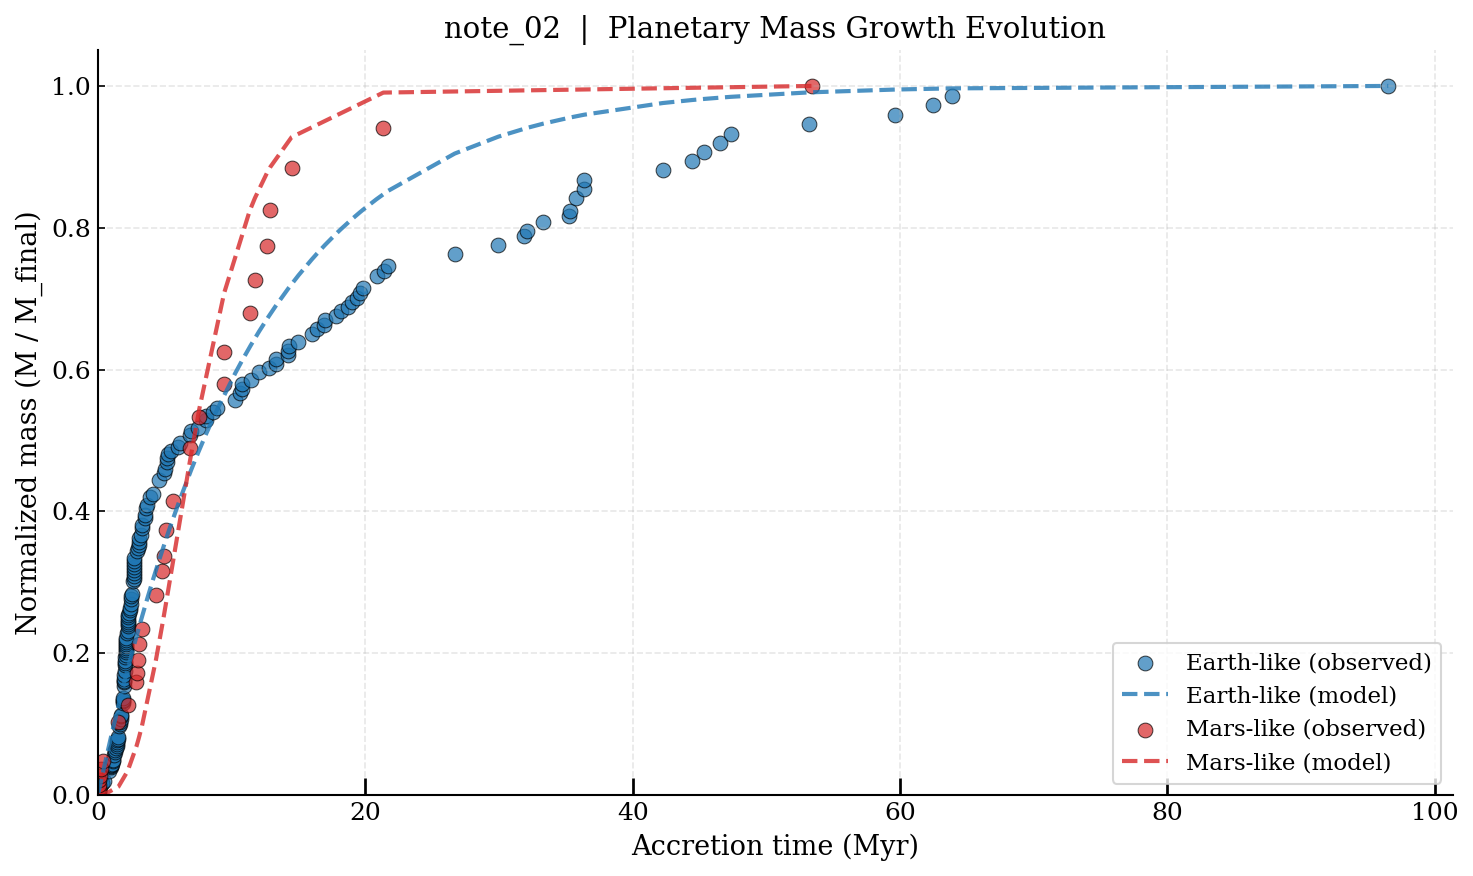

✓ Mass growth curves plotted



In [10]:
# ============================================================================
# SECTION 9a: VISUALIZATION - MASS GROWTH CURVES
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# ── Plot Earth-like ──────────────────────────────────────────────
if not Earth_like.empty:
    ax.scatter(Earth_like['Time'], Earth_like['M_ratio'], 
               label='Earth-like (observed)', color=Colors['Earth'], 
               s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.plot(Ea_t_val, m_Ea_model / m_Ea_model[-1], 
            label='Earth-like (model)', color=Colors['Earth'], 
            linestyle='--', linewidth=2, alpha=0.8)

# ── Plot Mars-like ──────────────────────────────────────────────
if not Mars_like.empty:
    ax.scatter(Mars_like['Time'], Mars_like['M_ratio'], 
               label='Mars-like (observed)', color=Colors['Mars'], 
               s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.plot(Ma_t_val, m_Ma_model / m_Ma_model[-1], 
            label='Mars-like (model)', color=Colors['Mars'], 
            linestyle='--', linewidth=2, alpha=0.8)

# ── Formatting ───────────────────────────────────────────────────
ax.set_xlabel('Accretion time (Myr)', fontsize=13)
ax.set_ylabel('Normalized mass (M / M_final)', fontsize=13)
ax.set_title(f'{Model}  |  Planetary Mass Growth Evolution', fontsize=14)
ax.set_xlim(0, ax.get_xlim()[1])
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, ls='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=11, loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

print(f"✓ Mass growth curves plotted")
print()

---
## 9b. Visualize Composition Evolution (Stacked Area Plot)

Show how chondrite fractions change during accretion as a stacked area plot.

**Interpretation:**
- Y-axis height represents contribution from each zone
- Smooth monotonic increase = steady accretion
- Discontinuities = major merger events

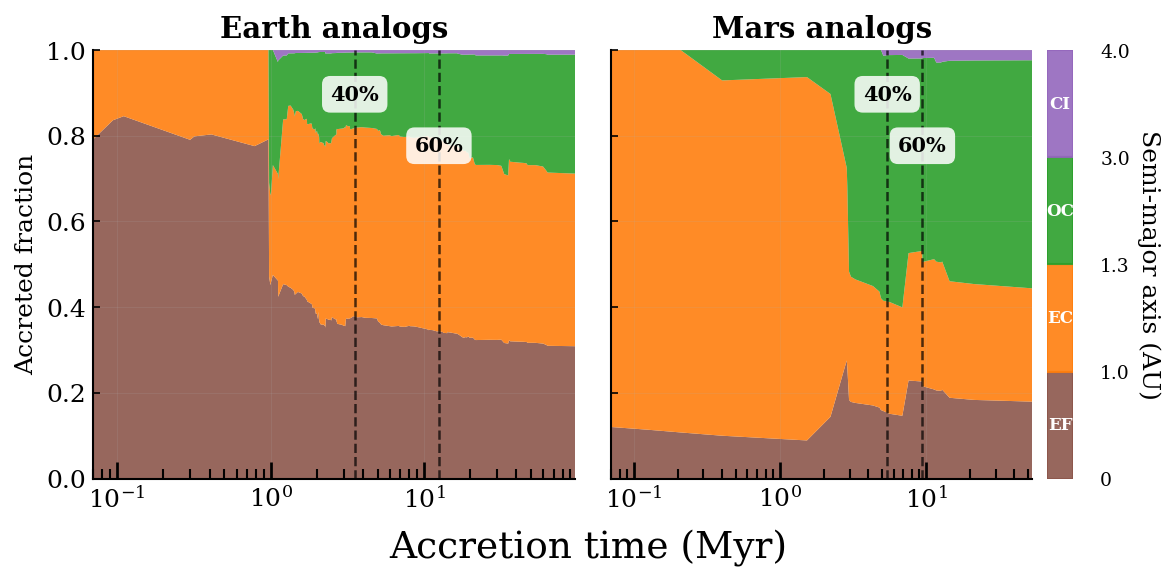

In [16]:
# ============================================================================
# SECTION 9b: VISUALIZATION - COMPOSITION EVOLUTION (修正版)
# ============================================================================

from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1. 提取成分比例列和颜色设置
frac_cols = ['EF_frac', 'EC_frac', 'OC_frac', 'CI_frac']
labels = ['EF', 'EC', 'OC', 'CI']
colors = [Colors['EF'], Colors['EC'], Colors['OC'], Colors['CI']]
n_colors = len(colors)

# 2. 获取 Earth_like 和 Mars_like 的索引
earth_idx = next((i for i, k in enumerate(keys_planets) if 'Earth_like' in k), None)
mars_idx = next((i for i, k in enumerate(keys_planets) if 'Mars_like' in k), None)

# 3. 创建左右双面板图形 - 关键修改：调整图尺寸和配置
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# 4. 定义绘图函数
def plot_composition_evolution(ax, planet_idx, title):
    df = pl_history_dict[keys_planets[planet_idx]].copy()
    planet_id = planets_index[planet_idx]
    df_planet = df[df['product_id'] == planet_id].copy()
    
    if df_planet.empty:
        df_planet = df.copy()
    
    df_planet = df_planet.sort_values('Time').reset_index(drop=True)
    time_data = df_planet['Time'].values
    fractions = df_planet[frac_cols].values.T
    
    ax.stackplot(time_data, fractions, colors=colors, alpha=0.9)
    ax.set_xscale('log')
    ax.set_xlim(0.07, time_data.max())
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.15, which='major', linestyle='-', linewidth=0.5)

# 5. 绘制左图：Earth analogs
if earth_idx is not None:
    plot_composition_evolution(axes[0], earth_idx, 'Earth analogs')
    axes[0].set_ylabel('Accreted fraction', fontsize=12)
    
    # 添加竖线及文本标注
    if not np.isnan(Ea_time_40):
        axes[0].axvline(Ea_time_40, color='k', linestyle='--', linewidth=1.2, alpha=0.7)
        axes[0].text(Ea_time_40, 0.92, '40%', ha='center', va='top', 
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                             edgecolor='none', alpha=0.85))
    
    if not np.isnan(Ea_time_60):
        axes[0].axvline(Ea_time_60, color='k', linestyle='--', linewidth=1.2, alpha=0.7)
        axes[0].text(Ea_time_60, 0.80, '60%', ha='center', va='top', 
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                             edgecolor='none', alpha=0.85))
else:
    axes[0].text(0.5, 0.5, 'No Earth analogs planet', ha='center', va='center', 
                transform=axes[0].transAxes, fontsize=11)
    axes[0].set_ylabel('Accreted fraction', fontsize=12)

# 6. 绘制右图：Mars analogs
if mars_idx is not None:
    plot_composition_evolution(axes[1], mars_idx, 'Mars analogs')
    
    # 添加竖线及文本标注
    if not np.isnan(Ma_time_40):
        axes[1].axvline(Ma_time_40, color='k', linestyle='--', linewidth=1.2, alpha=0.7)
        axes[1].text(Ma_time_40, 0.92, '40%', ha='center', va='top', 
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                             edgecolor='none', alpha=0.85))
    
    if not np.isnan(Ma_time_60):
        axes[1].axvline(Ma_time_60, color='k', linestyle='--', linewidth=1.2, alpha=0.7)
        axes[1].text(Ma_time_60, 0.80, '60%', ha='center', va='top', 
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                             edgecolor='none', alpha=0.85))
else:
    axes[1].text(0.5, 0.5, 'No Mars analogs planet', ha='center', va='center', 
                transform=axes[1].transAxes, fontsize=11)

# 7. 在右侧添加共享的 Color Bar
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="6%", pad=0.1)

for i, (color, label) in enumerate(zip(colors, labels)):
    cax.axhspan(i / n_colors, (i + 1) / n_colors, color=color, alpha=0.9)
    cax.text(0.5, (i + 0.5) / n_colors, label, 
             ha='center', va='center', fontsize=8, 
             color='white', fontweight='bold',
             transform=cax.transAxes)

cax.set_xlim(0, 1)
cax.set_ylim(0, 1)

# 8. 添加边界刻度
cax_tick = divider.append_axes("right", size="3%", pad=0.05)
cax_tick.set_ylim(0, 1)
cax_tick.set_xlim(0, 1)

tick_positions = [i / n_colors for i in range(n_colors + 1)]
tick_labels_au = ['0', '1.0', '1.3', '3.0', '4.0']

cax_tick.set_yticks(tick_positions)
cax_tick.set_yticklabels(tick_labels_au, fontsize=9)
cax_tick.yaxis.tick_right()
cax_tick.set_ylabel('Semi-major axis (AU)', fontsize=12, rotation=270, labelpad=15)
cax_tick.yaxis.set_label_position('right')

# 隐藏不需要的边框
cax.axis('off')
cax_tick.spines['top'].set_visible(False)
cax_tick.spines['bottom'].set_visible(False)
cax_tick.spines['left'].set_visible(False)
cax_tick.spines['right'].set_visible(False)
cax_tick.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
cax_tick.tick_params(axis='y', which='both', left=False, right=False, length=0)

# 9. 添加共享的 x 轴标题（居中于整个图形）
fig.text(0.5, 0.05, 'Accretion time (Myr)', ha='center', fontsize=18)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # 底部留出空间给共享标题
# plt.savefig(f'{Model}_Earth_Mars_composition_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 10. Export and Summary

Save all results to CSV for downstream analysis.

In [17]:
# ============================================================================
# SECTION 10: EXPORT & SUMMARY
# ============================================================================

# ── Build results dataframe ──────────────────────────────────────
results_data = []

# Earth-like entry
if not Earth_like.empty:
    results_data.append({
        'Planet_ID': Earth_like_index[0] if len(Earth_like_index) > 0 else np.nan,
        'Class': 'Earth_like',
        'Final_Mass_Mearth': Ea_final_mass,
        'Time_40pct_Myr': Ea_time_40,
        'Time_60pct_Myr': Ea_time_60,
        'Time_80pct_Myr': Ea_time_80,
        'Growth_tau_Myr': Ea_tau,
        'N_accretion_events': len(Earth_like),
        'EF_frac_final': Earth_like['EF_frac'].iloc[-1] if 'EF_frac' in Earth_like.columns else np.nan,
        'EC_frac_final': Earth_like['EC_frac'].iloc[-1] if 'EC_frac' in Earth_like.columns else np.nan,
        'OC_frac_final': Earth_like['OC_frac'].iloc[-1] if 'OC_frac' in Earth_like.columns else np.nan,
        'CI_frac_final': Earth_like['CI_frac'].iloc[-1] if 'CI_frac' in Earth_like.columns else np.nan,
    })

# Mars-like entry
if not Mars_like.empty:
    results_data.append({
        'Planet_ID': Mars_like_index[0] if len(Mars_like_index) > 0 else np.nan,
        'Class': 'Mars_like',
        'Final_Mass_Mearth': Ma_final_mass,
        'Time_40pct_Myr': Ma_time_40,
        'Time_60pct_Myr': Ma_time_60,
        'Time_80pct_Myr': Ma_time_80,
        'Growth_tau_Myr': Ma_tau,
        'N_accretion_events': len(Mars_like),
        'EF_frac_final': Mars_like['EF_frac'].iloc[-1] if 'EF_frac' in Mars_like.columns else np.nan,
        'EC_frac_final': Mars_like['EC_frac'].iloc[-1] if 'EC_frac' in Mars_like.columns else np.nan,
        'OC_frac_final': Mars_like['OC_frac'].iloc[-1] if 'OC_frac' in Mars_like.columns else np.nan,
        'CI_frac_final': Mars_like['CI_frac'].iloc[-1] if 'CI_frac' in Mars_like.columns else np.nan,
    })

df_results = pd.DataFrame(results_data)

# ── Export to CSV ────────────────────────────────────────────────
save_dir = pathlib.Path('./Tables')
save_dir.mkdir(parents=True, exist_ok=True)

filename = f'{Model}_evolution_timescales.csv'
save_file = save_dir / filename

df_results.to_csv(save_file, index=False)

print(f"✅ Exported: {save_file}")
print(f"  Rows    : {len(df_results)}")
print(f"  Columns : {len(df_results.columns)}")
print()

# Verify
data_verify = pd.read_csv(save_file)
print(f"✓ CSV verification: {len(data_verify)} planets loaded")
print()
print(df_results.to_string(index=False))
print()

# ── Summary statistics ───────────────────────────────────────────
print("=" * 80)
print("WORKFLOW SUMMARY: PLANETARY GROWTH EVOLUTION ANALYSIS")
print("=" * 80)
print()
print(f"Model                    : {Model}")
print(f"Simulation end time      : {time_end}")
print()
print(f"Initial conditions:")
print(f"  Planetesimals @ t=0    : {len(initial_composition)}")
print(f"  EF zone (a ≤ 1.0 AU)   : {sum(1 for p in initial_composition.values() if p.get('EF', 0) > 0)}")
print(f"  EC zone (1.0 < a ≤ 1.3): {sum(1 for p in initial_composition.values() if p.get('EC', 0) > 0)}")
print(f"  OC zone (1.3 < a ≤ 3.0): {sum(1 for p in initial_composition.values() if p.get('OC', 0) > 0)}")
print(f"  CI zone (a > 3.0 AU)   : {sum(1 for p in initial_composition.values() if p.get('CI', 0) > 0)}")
print()
print(f"Final planets @ t = {time_end}:")
print(f"  Total identified       : {len(planets_index)}")
print(f"  Earth-like (m ∈ [0.7, 1.3] M⊕)  : {len(Earth_like_index)}")
print(f"  Mars-like (m ∈ [0.05, 0.3] M⊕)   : {len(Mars_like_index)}")
print()
print(f"Accretion analysis:")
print(f"  Post-gas disk collisions: {len(collision_df)}")
print(f"  Composition tracking    : {len(composition_types)} chondrite types")
print()
if not df_results.empty:
    print("Final results:")
    print(df_results[['Class', 'Final_Mass_Mearth', 'Time_60pct_Myr', 'Growth_tau_Myr']].to_string(index=False))
print()
print("Output file:")
print(f"  {save_file}")
print()
print("=" * 80)
print("✅ Workflow complete. Planetary growth evolution analysis ready for publication.")
print("=" * 80)

✅ Exported: Tables/note_02_evolution_timescales.csv
  Rows    : 2
  Columns : 12

✓ CSV verification: 2 planets loaded

 Planet_ID      Class  Final_Mass_Mearth  Time_40pct_Myr  Time_60pct_Myr  Time_80pct_Myr  Growth_tau_Myr  N_accretion_events  EF_frac_final  EC_frac_final  OC_frac_final  CI_frac_final
      4189 Earth_like          61.798152        3.534676       12.506029       32.520004       11.365746                 158       0.309066       0.402594       0.277477       0.010863
      4755  Mars_like           1.415515        5.420232        9.437176       12.768667        6.610088                  31       0.179738       0.264301       0.532078       0.023882

WORKFLOW SUMMARY: PLANETARY GROWTH EVOLUTION ANALYSIS

Model                    : note_02
Simulation end time      : 100.0 Myr

Initial conditions:
  Planetesimals @ t=0    : 7000
  EF zone (a ≤ 1.0 AU)   : 2511
  EC zone (1.0 < a ≤ 1.3): 2493
  OC zone (1.3 < a ≤ 3.0): 1506
  CI zone (a > 3.0 AU)   : 490

Final planets @ 